## Importing nessecary modules
Make sure you have the necessary modules and data.

In [27]:
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from dataPath import DATA_PATH
from IPython.display import display
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import StatisticalResult, logrank_test
from sksurv.ensemble import RandomSurvivalForest
from sksurv.datasets import load_whas500
from sksurv.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance


### Load data

In [5]:
# Read the data
radcure_clinical_raw = pd.read_excel(DATA_PATH, "RADCURE_TCIA_Clinical_r2_offset")

### Explore the code

In [6]:
print(radcure_clinical_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3346 entries, 0 to 3345
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   patient_id         3346 non-null   object        
 1   Age                3346 non-null   float64       
 2   Sex                3346 non-null   object        
 3   ECOG PS            3345 non-null   object        
 4   Smoking PY         3341 non-null   object        
 5   Smoking Status     3346 non-null   object        
 6   Ds Site            3346 non-null   object        
 7   Subsite            2972 non-null   object        
 8   T                  3334 non-null   object        
 9   N                  3333 non-null   object        
 10  M                  3332 non-null   object        
 11  Stage              3319 non-null   object        
 12  Path               3346 non-null   object        
 13  HPV                1717 non-null   object        
 14  Tx Modal

In [11]:
with pd.option_context("display.max_rows", None, "display.max_columns", None):
  display(radcure_clinical_raw.head(5))

,patient_id,Age,Sex,ECOG PS,Smoking PY,Smoking Status,Ds Site,Subsite,T,N,M,Stage,Path,HPV,Tx Modality,Chemo,RT Start,Dose,Fx,Last FU,Status,Length FU,Date of Death,Cause of Death,Local,Date Local,Regional,Date Regional,Distant,Date Distant,2nd Ca,Date 2nd Ca,RADCURE-challenge,ContrastEnhanced
0,RADCURE-0005,62.6,Female,ECOG 0,50,Ex-smoker,Oropharynx,post wall,T4b,N2c,M0,IVB,Squamous Cell Carcinoma,"Yes, Negative",RT alone,none,2002-02-20,60.0,25,2003-05-12,Dead,1.317808,2003-05-12,Other Cause,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,0,0
1,RADCURE-0006,87.3,Male,ECOG 2,25,Ex-smoker,Larynx,Glottis,T1b,N0,M0,I,Squamous Cell Carcinoma,NaN,RT alone,none,2006-01-17,51.0,20,2007-06-28,Dead,1.520548,2007-06-28,Other Cause,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,0,1
2,RADCURE-0007,49.9,Male,ECOG 1,15,Ex-smoker,Oropharynx,Tonsil,T3,N2b,M0,IVA,Squamous Cell Carcinoma,"Yes, positive",RT alone,none,2009-11-09,64.0,40,2011-12-05,Alive,2.126027,NaT,NaN,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,0,1
3,RADCURE-0009,72.3,Male,ECOG 1,30,Ex-smoker,Unknown,NaN,T0,N2c,M0,IVA,Squamous Cell Carcinoma,NaN,RT alone,none,2002-10-07,70.0,35,2008-05-27,Alive,5.791781,NaT,NaN,NaN,NaT,NaN,NaT,NaN,NaT,S (suspicious),2008-05-27,0,0
4,RADCURE-0010,59.7,Female,ECOG 0,0,Non-smoker,Oropharynx,Tonsillar Fossa,T4b,N0,M0,IVB,Squamous Cell Carcinoma,"Yes, Negative",RT alone,none,2000-12-19,64.0,40,2010-05-25,Alive,9.512329,NaT,NaN,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,0,0


### Assert the data invariants that this analysis relies on

Ensure that the dataset has exactly 1 entry for each patient.

In [8]:
assert (
  radcure_clinical_raw["patient_id"].unique().shape[0] == radcure_clinical_raw["patient_id"].size
), "The dataset has duplicated entries for some patients."

Ensure that `Tx Modality` does not have missing values.

In [9]:
assert (
  radcure_clinical_raw["Tx Modality"].dropna().shape[0] == radcure_clinical_raw["Tx Modality"].size
), "The dataset has entries without Tx Modality."

Ensure that the `Status` column contains only values `Alive` and `Dead`.

In [10]:
assert set(radcure_clinical_raw["Status"].unique()) == {
  "Alive",
  "Dead",
}, "The dataset contains unexpected values in the Status column. It must contian only Dead and Alive"

### Preprocess data for analysis

In [12]:
# To be safe, remove all rows that do not have values for the "key" columns and make a copy of the original data
radcure_clinical = radcure_clinical_raw.dropna(subset=["Status", "Tx Modality"]).copy(deep=True)

# Trim values of the Tx Modality column to remove aliases
radcure_clinical["Tx Modality"] = radcure_clinical_raw["Tx Modality"].str.strip()

# Map categorical values for patient status to boolean values to be used in Kaplan-Meier analysis
radcure_clinical["isDead"] = radcure_clinical_raw["Status"].map({"Alive": False, "Dead": True}).fillna(value=False)

print(radcure_clinical.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3346 entries, 0 to 3345
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   patient_id         3346 non-null   object        
 1   Age                3346 non-null   float64       
 2   Sex                3346 non-null   object        
 3   ECOG PS            3345 non-null   object        
 4   Smoking PY         3341 non-null   object        
 5   Smoking Status     3346 non-null   object        
 6   Ds Site            3346 non-null   object        
 7   Subsite            2972 non-null   object        
 8   T                  3334 non-null   object        
 9   N                  3333 non-null   object        
 10  M                  3332 non-null   object        
 11  Stage              3319 non-null   object        
 12  Path               3346 non-null   object        
 13  HPV                1717 non-null   object        
 14  Tx Modal

In [13]:
with pd.option_context("display.max_rows", None, "display.max_columns", None):
  display(radcure_clinical.head(5))

,patient_id,Age,Sex,ECOG PS,Smoking PY,Smoking Status,Ds Site,Subsite,T,N,M,Stage,Path,HPV,Tx Modality,Chemo,RT Start,Dose,Fx,Last FU,Status,Length FU,Date of Death,Cause of Death,Local,Date Local,Regional,Date Regional,Distant,Date Distant,2nd Ca,Date 2nd Ca,RADCURE-challenge,ContrastEnhanced,isDead
0,RADCURE-0005,62.6,Female,ECOG 0,50,Ex-smoker,Oropharynx,post wall,T4b,N2c,M0,IVB,Squamous Cell Carcinoma,"Yes, Negative",RT alone,none,2002-02-20,60.0,25,2003-05-12,Dead,1.317808,2003-05-12,Other Cause,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,0,0,True
1,RADCURE-0006,87.3,Male,ECOG 2,25,Ex-smoker,Larynx,Glottis,T1b,N0,M0,I,Squamous Cell Carcinoma,NaN,RT alone,none,2006-01-17,51.0,20,2007-06-28,Dead,1.520548,2007-06-28,Other Cause,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,0,1,True
2,RADCURE-0007,49.9,Male,ECOG 1,15,Ex-smoker,Oropharynx,Tonsil,T3,N2b,M0,IVA,Squamous Cell Carcinoma,"Yes, positive",RT alone,none,2009-11-09,64.0,40,2011-12-05,Alive,2.126027,NaT,NaN,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,0,1,False
3,RADCURE-0009,72.3,Male,ECOG 1,30,Ex-smoker,Unknown,NaN,T0,N2c,M0,IVA,Squamous Cell Carcinoma,NaN,RT alone,none,2002-10-07,70.0,35,2008-05-27,Alive,5.791781,NaT,NaN,NaN,NaT,NaN,NaT,NaN,NaT,S (suspicious),2008-05-27,0,0,False
4,RADCURE-0010,59.7,Female,ECOG 0,0,Non-smoker,Oropharynx,Tonsillar Fossa,T4b,N0,M0,IVB,Squamous Cell Carcinoma,"Yes, Negative",RT alone,none,2000-12-19,64.0,40,2010-05-25,Alive,9.512329,NaT,NaN,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,0,0,False


## 1. Kaplan-Meier Analysis

In [14]:
def plot_kaplan_meier_log_rank_test(
  radcure_clinical_dataset: pd.DataFrame,
  covariate: str,
  plot_title: str | None = None,
  significance_level: float = 0.05,
) -> dict[tuple[str, str], StatisticalResult]:
  dataset_with_relevant_columns = radcure_clinical_dataset[["Length FU", "isDead", covariate]]
  dataset_with_relevant_columns_no_na = dataset_with_relevant_columns.dropna()

  groups = dataset_with_relevant_columns_no_na[covariate].unique()

  def plot_kaplan_meier() -> None:
    kmf = KaplanMeierFitter(alpha=significance_level, label=covariate)

    for group in groups:
      group_value_mask = dataset_with_relevant_columns_no_na[covariate] == group

      kmf.fit(
        durations=dataset_with_relevant_columns_no_na.loc[group_value_mask, "Length FU"],
        event_observed=dataset_with_relevant_columns_no_na.loc[group_value_mask, "isDead"],
        label=f"{group}",
      )
      kmf.plot()

    plt.title(plot_title or f"Kaplan-Meier Survival Curves for {covariate}")
    plt.xlabel("Years since diagnosis until death")
    plt.ylabel("Survival probability")
    plt.show()

  def log_rank_between_groups() -> dict[tuple[str, str], StatisticalResult]:
    logrank_results: dict[tuple[str, str], StatisticalResult] = {}

    for group_a, group_b in combinations(groups, 2):
      mask_group_a = dataset_with_relevant_columns_no_na[covariate] == group_a
      mask_group_b = dataset_with_relevant_columns_no_na[covariate] == group_b

      logrank_results[(group_a, group_b)] = logrank_test(
        durations_A=dataset_with_relevant_columns_no_na.loc[mask_group_a, "Length FU"],
        durations_B=dataset_with_relevant_columns_no_na.loc[mask_group_b, "Length FU"],
        event_observed_A=dataset_with_relevant_columns_no_na.loc[mask_group_a, "isDead"],
        event_observed_B=dataset_with_relevant_columns_no_na.loc[mask_group_b, "isDead"],
      )

    return logrank_results

  plot_kaplan_meier()
  return log_rank_between_groups()


def print_log_rank_results(
  groups_log_rank_results: dict[tuple[str, str], StatisticalResult],
  covariate: str,
  significance_level: float = 0.05,
) -> None:
  print(
    f"Note: this analysis assumes that the assumption of proportional hazards holds for the data, therefore the analysis performs log-rank test for all combinations of groups for the {covariate} covariate. Later, in the 2. Cox Proportional Hazards Regression secton this notebook will validate the assumption."
  )

  for (group_a, group_b), logrank_result in groups_log_rank_results.items():
    print(f"{group_a} vs {group_b}")
    logrank_result.print_summary()

    if logrank_result.p_value >= significance_level:
      print(
        f"Conclusion: given the observed data, there is no statistically significant difference in survival distributions between group {group_a} and {group_b}."
      )
    else:
      print(f"Conclusion: there is a difference in survival distributions for groups {group_a} and {group_b}.")

#### Tx Modality group

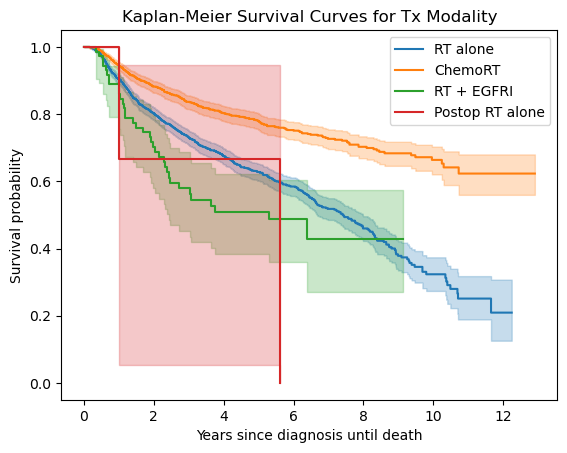

Note: this analysis assumes that the assumption of proportional hazards holds for the data, therefore the analysis performs log-rank test for all combinations of groups for the Tx Modality covariate. Later, in the 2. Cox Proportional Hazards Regression secton this notebook will validate the assumption.
RT alone vs ChemoRT


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         115.96 <0.005     87.41

Conclusion: there is a difference in survival distributions for groups RT alone and ChemoRT.
RT alone vs RT + EGFRI


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           4.53 0.03      4.91

Conclusion: there is a difference in survival distributions for groups RT alone and RT + EGFRI.
RT alone vs Postop RT alone


...

Conclusion: there is a difference in survival distributions for groups ChemoRT and RT + EGFRI.
ChemoRT vs Postop RT alone


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           5.38 0.02      5.61

Conclusion: there is a difference in survival distributions for groups ChemoRT and Postop RT alone.
RT + EGFRI vs Postop RT alone


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.54 0.46      1.11

Conclusion: given the observed data, there is no statistically significant difference in survival distributions between group RT + EGFRI and Postop RT alone.


In [15]:
tx_modality_logrank_results = plot_kaplan_meier_log_rank_test(
  radcure_clinical, covariate="Tx Modality", significance_level=0.05
)
print_log_rank_results(tx_modality_logrank_results, covariate="Tx Modality", significance_level=0.05)

#### Stage group

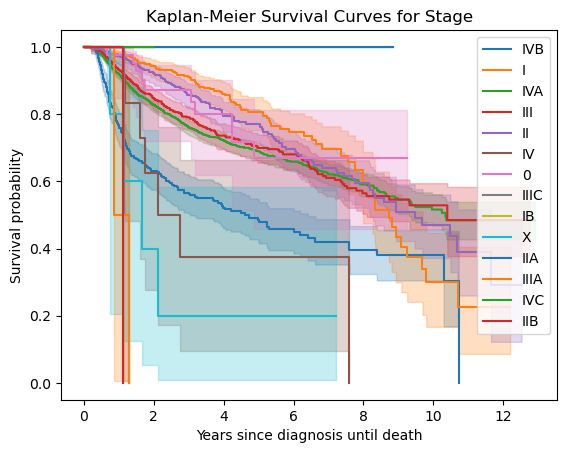

Note: this analysis assumes that the assumption of proportional hazards holds for the data, therefore the analysis performs log-rank test for all combinations of groups for the Stage covariate. Later, in the 2. Cox Proportional Hazards Regression secton this notebook will validate the assumption.
IVB vs I


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          64.30 <0.005     49.73

Conclusion: there is a difference in survival distributions for groups IVB and I.
IVB vs IVA


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          62.52 <0.005     48.43

Conclusion: there is a difference in survival distributions for groups IVB and IVA.
IVB vs III


...

Conclusion: given the observed data, there is no statistically significant difference in survival distributions between group IIIA and IVC.
IIIA vs IIB


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.06 0.81      0.31

Conclusion: given the observed data, there is no statistically significant difference in survival distributions between group IIIA and IIB.
IVC vs IIB


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           2.00 0.16      2.67

Conclusion: given the observed data, there is no statistically significant difference in survival distributions between group IVC and IIB.


In [16]:
stage_logrank_results = plot_kaplan_meier_log_rank_test(radcure_clinical, covariate="Stage", significance_level=0.05)
print_log_rank_results(stage_logrank_results, covariate="Stage", significance_level=0.05)

## 2. Cox Proportional Hazards Regression

In [17]:
cph_radcure_clinical = (
  radcure_clinical[["Length FU", "isDead", "Tx Modality", "Stage", "Sex"]]
  .dropna()
  .astype({c: "category" for c in ["Tx Modality", "Stage", "Sex"]})
)
cph_radcure_clinical.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3319 entries, 0 to 3345
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Length FU    3319 non-null   float64 
 1   isDead       3319 non-null   bool    
 2   Tx Modality  3319 non-null   category
 3   Stage        3319 non-null   category
 4   Sex          3319 non-null   category
dtypes: bool(1), category(3), float64(1)
memory usage: 65.8 KB


Note: The omitted category acts as the baseline or reference category against which all other categories are compared.

Therefore, we will explicitly drop the following categories in the corresponding covatiates:
- `ChemoRT` for the `Tx Modality` covariate, because the Kaplan-Meier analysis suggested that the patients who got this treatment have "the best" survival distribution.
- `0` for the `Stage` covariate, as the lowest stage.
- `Male` for the `Sex` covariate. This analysis makes an assumption that this covariate does not make a significant difference, so any value can be dropped.

In [18]:
cph_radcure_clinical_encoded = pd.get_dummies(
  cph_radcure_clinical, drop_first=False, columns=["Tx Modality", "Stage", "Sex"], prefix_sep="_"
)
cph_radcure_clinical_encoded = cph_radcure_clinical_encoded.drop(columns=["Tx Modality_ChemoRT", "Stage_0", "Sex_Male"])

cph_radcure_clinical_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3319 entries, 0 to 3345
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Length FU                    3319 non-null   float64
 1   isDead                       3319 non-null   bool   
 2   Tx Modality_Postop RT alone  3319 non-null   bool   
 3   Tx Modality_RT + EGFRI       3319 non-null   bool   
 4   Tx Modality_RT alone         3319 non-null   bool   
 5   Stage_I                      3319 non-null   bool   
 6   Stage_IB                     3319 non-null   bool   
 7   Stage_II                     3319 non-null   bool   
 8   Stage_IIA                    3319 non-null   bool   
 9   Stage_IIB                    3319 non-null   bool   
 10  Stage_III                    3319 non-null   bool   
 11  Stage_IIIA                   3319 non-null   bool   
 12  Stage_IIIC                   3319 non-null   bool   
 13  Stage_IV               

In [19]:
cph_significance_level = 0.05
cph = CoxPHFitter(
  alpha=cph_significance_level,
  baseline_estimation_method="breslow",
)

In [20]:
cph.fit(
  cph_radcure_clinical_encoded,
  duration_col="Length FU",
  event_col="isDead",
)

<lifelines.CoxPHFitter: fitted with 3319 total observations, 2269 right-censored observations>

<lifelines.CoxPHFitter: fitted with 3319 total observations, 2269 right-censored observations>
             duration col = 'Length FU'
                event col = 'isDead'
      baseline estimation = breslow
   number of observations = 3319
number of events observed = 1050
   partial log-likelihood = -7721.93
         time fit was run = 2025-04-03 01:36:52 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
Tx Modality_Postop RT alone   2.22      9.22      0.71            0.83            3.62                2.28               37.22
Tx Modality_RT + EGFRI        0.99      2.70      0.18            0.64            1.34                1.90                3.83
Tx Modality_RT alone          1.11      3.04      0.07            0.97            1.26                2.63                3.51
Stage_I                      -0.17      0.84      0.34           -0.83            0.49                0.44                1.62
Stage_IB                    -17.35      0.00  19673.65       -38577.01        38542.30                0.00                 inf
Stage_II                      0.08      1.09      0.33           -0.56            0.73                0.57                2.08
Stage_IIA                   -11.03      0.00    569.85        -1127.92         1105.87                0.00                 inf
Stage_IIB                     2.63     13.87      1.05            0.57            4.69                1.77              108.60
Stage_III                     0.49      1.64      0.33           -0.15            1.13                0.86                3.09
Stage_IIIA                    3.19     24.39      0.78            1.67            4.72                5.32              111.85
Stage_IIIC                    2.86     17.50      0.78            1.34            4.38                3.82               80.10
Stage_IV                      1.63      5.10      0.49            0.66            2.60                1.94               13.42
Stage_IVA                     0.77      2.16      0.32            0.14            1.40                1.15                4.05
Stage_IVB                     1.60      4.98      0.33            0.96            2.25                2.61                9.48
Stage_IVC                   -12.73      0.00   1384.36        -2726.02         2700.56                0.00                 inf
Stage_X                       1.71      5.53      0.59            0.55            2.87                1.73               17.66
Sex_Female                   -0.04      0.96      0.08           -0.19            0.11                0.82                1.12

                             cmp to     z      p  -log2(p)
covariate                                                 
Tx Modality_Postop RT alone    0.00  3.12 <0.005      9.11
Tx Modality_RT + EGFRI         0.00  5.55 <0.005     25.03
Tx Modality_RT alone           0.00 15.17 <0.005    170.25
Stage_I                        0.00 -0.52   0.61      0.72
Stage_IB                       0.00 -0.00   1.00      0.00
Stage_II                       0.00  0.26   0.80      0.33
Stage_IIA                      0.00 -0.02   0.98      0.02
Stage_IIB                      0.00  2.50   0.01      6.35
Stage_III                      0.00  1.51   0.13      2.94
Stage_IIIA                     0.00  4.11 <0.005     14.63
Stage_IIIC                     0.00  3.69 <0.005     12.11
Stage_IV                       0.00  3.30 <0.005     10.01
Stage_IVA                      0.00  2.40   0.02      5.91
Stage_IVB                      0.00  4.88 <0.005     19.87
Stage_IVC                      0.00 -0.01   0.99      0.01
Stage_X                        0.00  2.89 <0.005      8.01
Sex_Female                     0.00 -0.51   0.61      0.72
---
Concordance = 0.67
Partial AIC = 15477.87
log-likelihood ratio test = 359.68 on 17 df
-log2(p

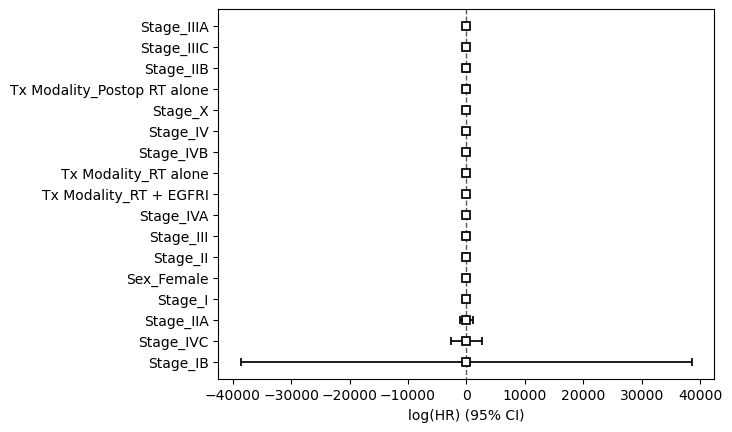

In [21]:
cph.plot()
cph.print_summary(decimals=2)

### Validate the proportional hazards assumption


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations,

<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 3319 total observations, 2269 right-censored observations>
         test_name = proportional_hazard_test

---
                                  test_statistic    p  -log2(p)
Sex_Female                  km              2.62 0.11      3.24
                            rank            2.88 0.09      3.48
Stage_I                     km              1.31 0.25      1.98
                            rank            0.50 0.48      1.06
Stage_IB                    km              0.00 1.00      0.00
                            rank            0.00 1.00      0.00
Stage_II                    km              0.26 0.61      0.72
                            rank            0.06 0.81      0.30
Stage_IIA                   km              0.00 1.00      0.00
                            rank            0.00 1.00      0.00
Stage_IIB                   km              0.00 0.96      0.06
                            rank            0.01 0.93      0.11
Stage_III                   km              0.54 0.46      1.11
                            rank            0.92 0.34      1.57
Stage_IIIA                  km              0.01 0.91      0.14
                            rank            0.02 0.88      0.18
Stage_IIIC                  km              0.01 0.91      0.14
                            rank            0.02 0.87      0.19
Stage_IV                    km              0.02 0.88      0.18
                            rank            0.00 0.98      0.03
Stage_IVA                   km              1.15 0.28      1.82
                            rank            1.86 0.17      2.54
Stage_IVB                   km              3.25 0.07      3.81
                            rank            5.15 0.02      5.43
Stage_IVC                   km              0.00 1.00      0.00
                            rank            0.00 1.00      0.00
Stage_X                     km              1.16 0.28      1.83
                            rank            1.42 0.23      2.10
Tx Modality_Postop RT alone km              0.45 0.50      0.99
                            rank            0.45 0.50      1.00
Tx Modality_RT + EGFRI      km              0.02 0.89      0.16
                            rank            0.06 0.81      0.30
Tx Modality_RT alone        km              0.28 0.60      0.74
                            rank            0.03 0.85      0.23



1. Variable 'Stage_IVB' failed the non-proportional test: p-value is 0.0232.

   Advice: with so few unique values (only 2), you can include `strata=['Stage_IVB', ...]` in the
call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20haza

[[<Axes: xlabel='rank-transformed time\n(p=0.5012)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5045)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8139)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8943)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8519)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5988)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4801)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2532)'>],
 [<Axes: xlabel='rank-transformed time\n(p=1.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=1.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8138)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6086)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9987)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9989)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9270)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9578)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3375)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4644)'>],
 [<Axes: xlabel='rank-transformed tim

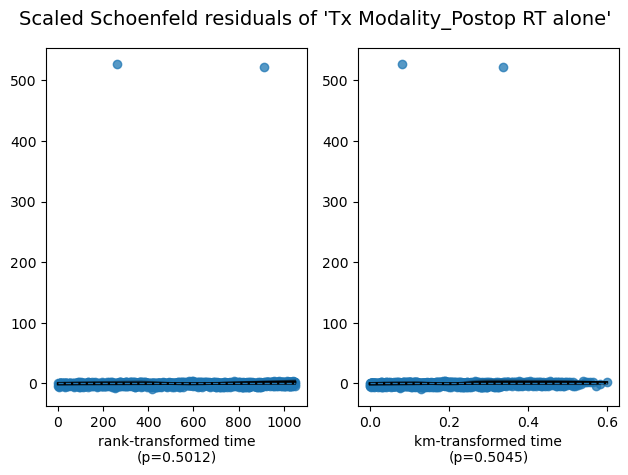

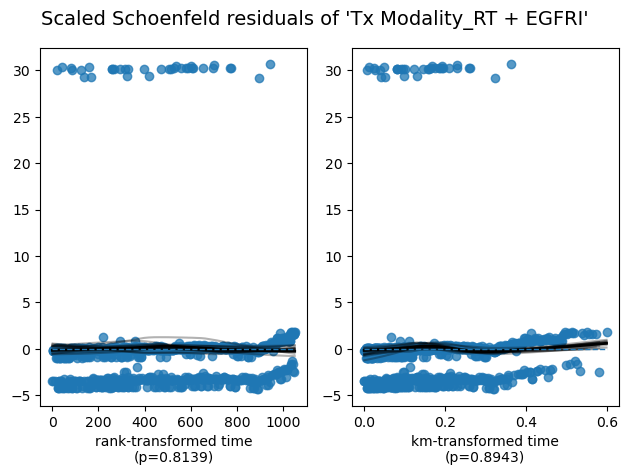

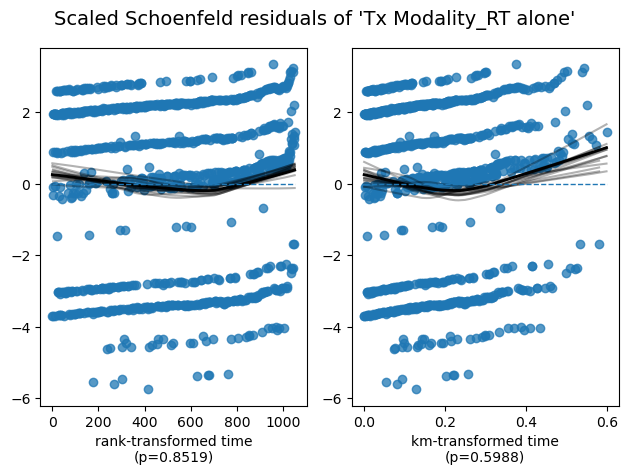

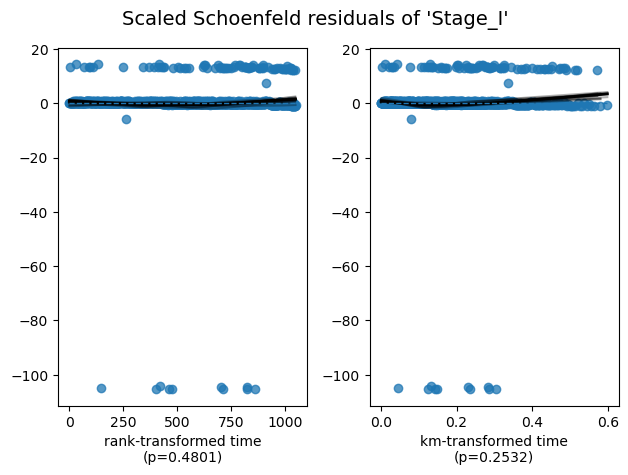

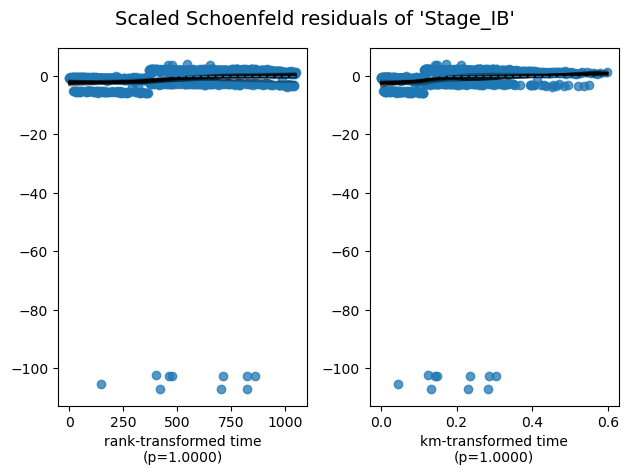

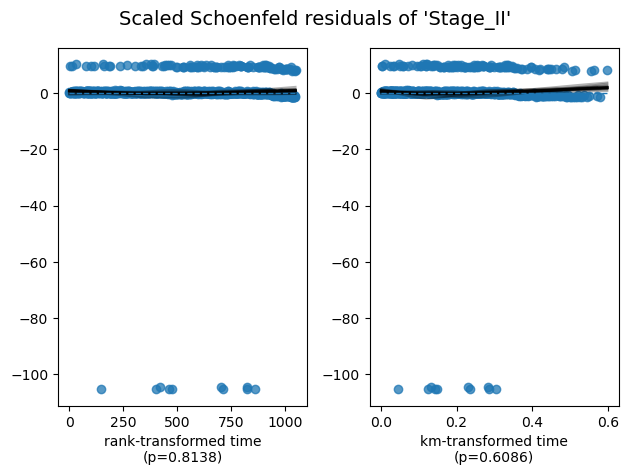

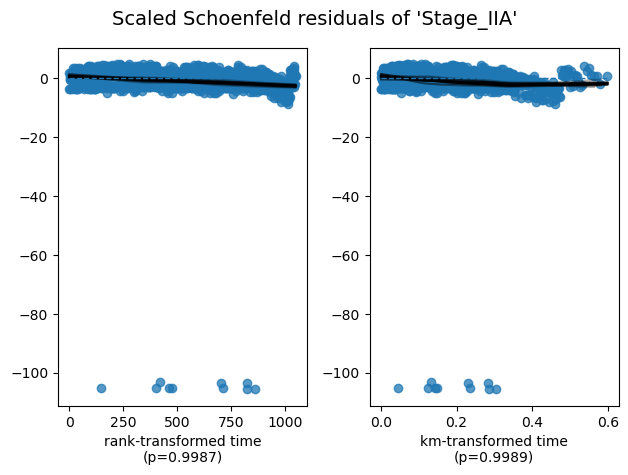

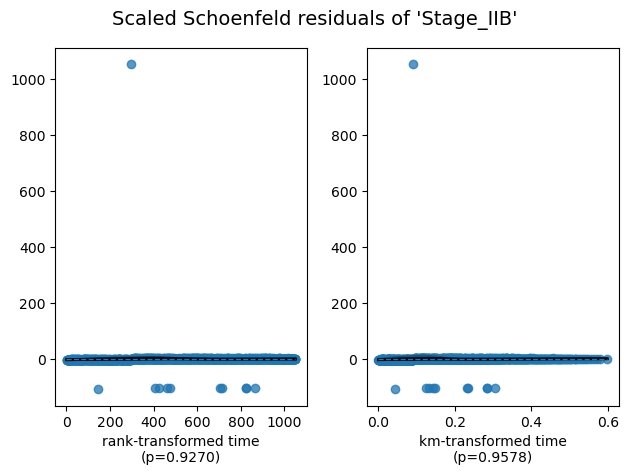

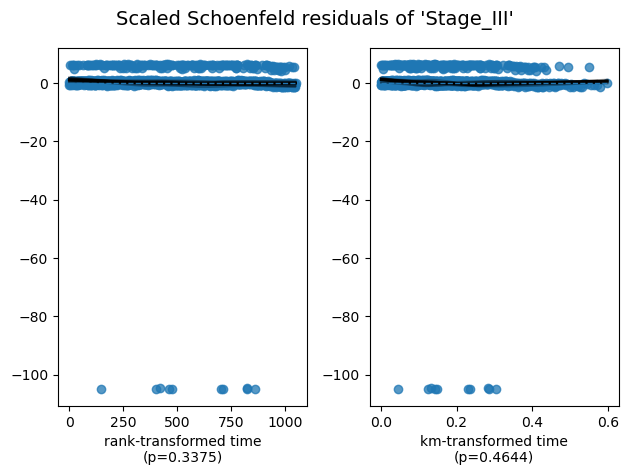

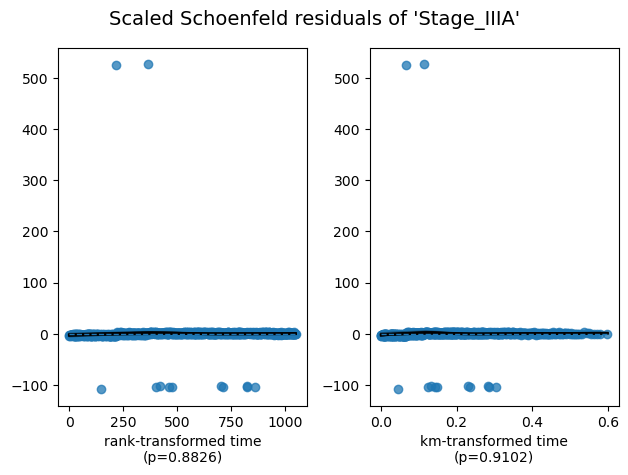

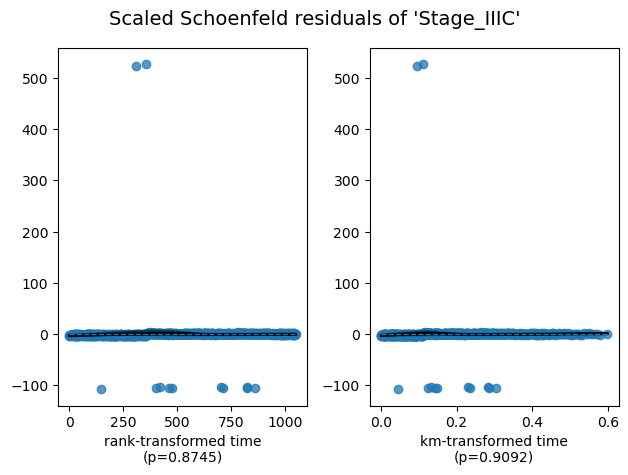

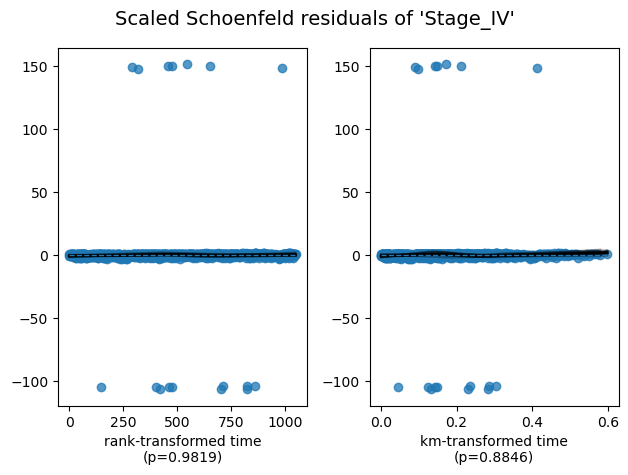

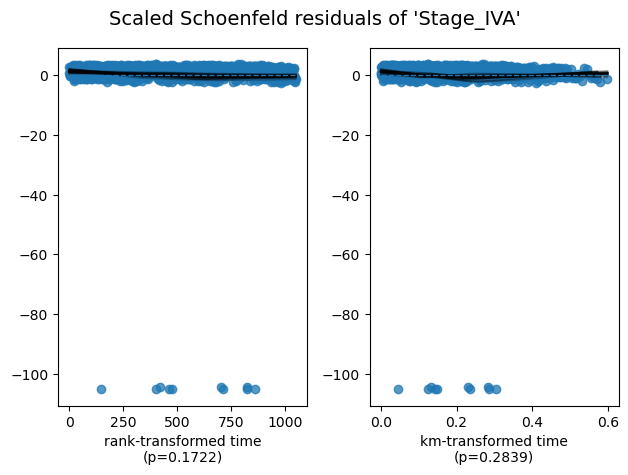

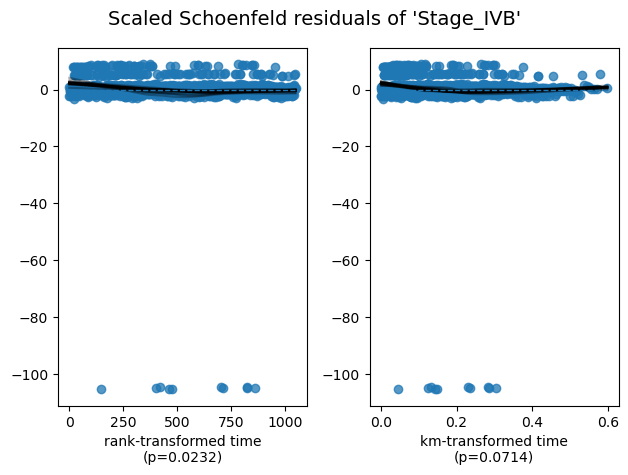

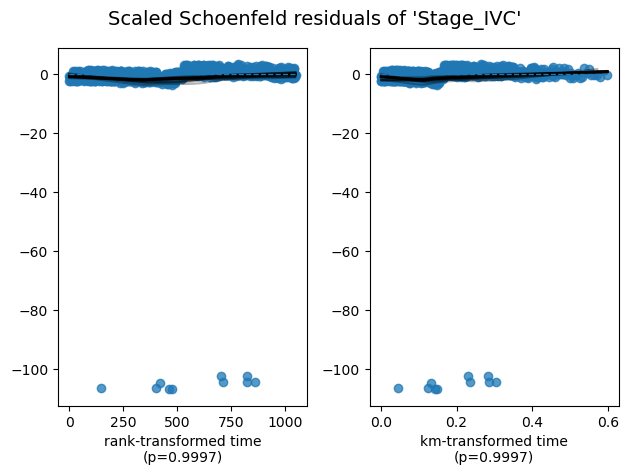

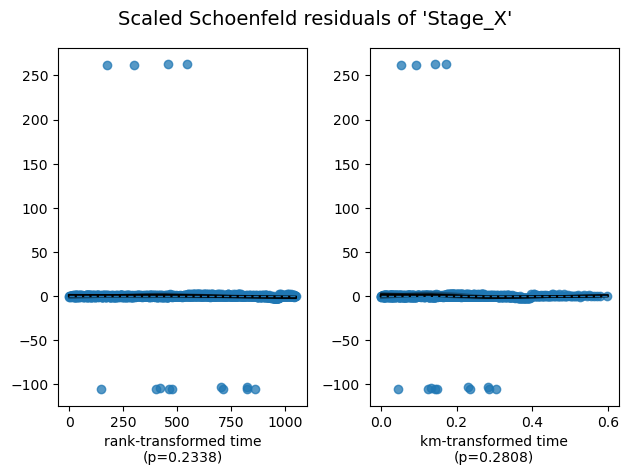

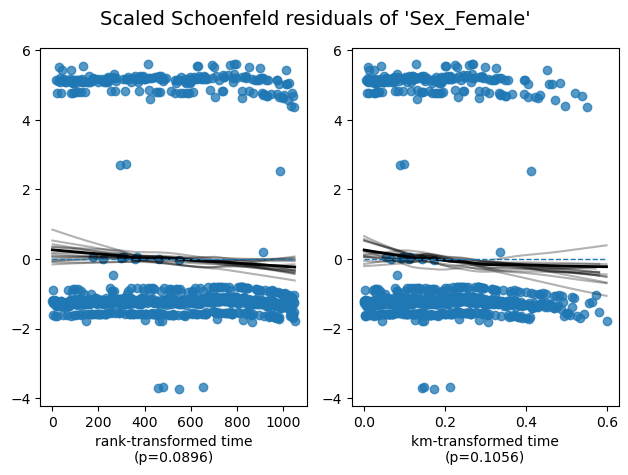

In [22]:
cph_assumptions_check_result = cph.check_assumptions(
  cph_radcure_clinical_encoded,
  p_value_threshold=cph_significance_level,
  show_plots=True,
)
cph_assumptions_check_result

Given the above analysis of the proportional hazards assumption above, it looks like the group of `IVB` in the `Stage` covariate violates the assumption. This makes sense, and the argument can even be scaled to more `Stage` groups given enough data. Theoretically, this makes sense, beacuse patients at higher cancer stages, can have their hazard functions vary with time due to the changes of tumor over time.

In this case, the values of the hazard functions of the Cox model can be interpreted as averaged over time for the given dataset. This means that the predictions may not be accurately scaled to new data and the model does not accurately caplure how the relationships change over time. Similarly, the results of the signifiance tests may not be reliable, so the drawn conclusions may not hold in reality.

Due to violation of the proportional hazards assumption, Cox's model does not apply well to the given problem.

This notebook will try random survival forests model, which does not rely on the proportional hazards assumption.

## 3. Random Survival Forests (RSF)

In [23]:
# Load the radcure dataset
data_x, data_y = radcure_clinical

# Encode categorical variables
encoder = OneHotEncoder()
data_x = encoder.fit_transform(data_x)

# Train a Random Survival Forest model
rsf = RandomSurvivalForest(n_estimators=100, random_state=42)
rsf.fit(data_x, data_y)

# please refer to https://scikit-survival.readthedocs.io/en/stable/user_guide/random-survival-forest.html
result = permutation_importance(rsf, data_x, data_y, n_repeats=15, random_state=42)
feature_importance = pd.DataFrame(
         {
        k: result[k]
        for k in (
            "importances_mean",
            "importances_std",
        )
    },
    index=data_x.columns,
).sort_values(by="importances_mean", ascending=False)

# Sort by importances_mean and plot
feature_importance = feature_importance.sort_values(by="importances_mean", ascending=False)

plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(feature_importance.index, feature_importance['importances_mean'], xerr=feature_importance['importances_std'], align='center')
plt.xlabel('Mean Importance')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


ValueError: too many values to unpack (expected 2)

In [24]:
print(type(radcure_clinical))
print(len(radcure_clinical))  # Check how many elements are being returned


<class 'pandas.core.frame.DataFrame'>
3346


In [25]:
print(radcure_clinical.columns)


Index(['patient_id', 'Age', 'Sex', 'ECOG PS', 'Smoking PY', 'Smoking Status',
       'Ds Site', 'Subsite', 'T', 'N', 'M ', 'Stage', 'Path', 'HPV',
       'Tx Modality', 'Chemo', 'RT Start', 'Dose', 'Fx', 'Last FU', 'Status',
       'Length FU', 'Date of Death', 'Cause of Death', 'Local', 'Date Local',
       'Regional', 'Date Regional', 'Distant', 'Date Distant', '2nd Ca',
       'Date 2nd Ca', 'RADCURE-challenge', 'ContrastEnhanced', 'isDead'],
      dtype='object')


In [37]:
# Define survival time and event columns
time_column = "Length FU"  # Time-to-event
event_column = "isDead"  # Censoring indicator (1 = event occurred, 0 = censored)

# Convert event column to boolean (scikit-survival requires True/False)
radcure_clinical[event_column] = radcure_clinical[event_column].astype(bool)

# Remove non-feature columns (e.g., patient_id, time, event indicator)
non_feature_columns = ["patient_id", time_column, event_column]
data_x = radcure_clinical.drop(columns=non_feature_columns)

# Create a structured array for survival target variable
data_y = np.array(
    list(zip(radcure_clinical[event_column], radcure_clinical[time_column])),
    dtype=[("Status", "?"), ("Time", "<f8")]
)

In [40]:

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Define categorical columns
categorical_cols = ["Sex", "ECOG PS", "Smoking Status", "Ds Site", "Subsite",
                    "T", "N", "M", "Stage", "Path", "HPV", "Tx Modality", "Chemo"]

# Trim spaces from column names
radcure_clinical.columns = radcure_clinical.columns.str.strip()

# Convert columns to 'category' and add "Unknown" as a category before filling NaNs
for col in categorical_cols:
    # Ensure column is explicitly converted to 'category'
    radcure_clinical[col] = radcure_clinical[col].astype('category')
    
    # Add "Unknown" as a category if it's not already a category
    if "Unknown" not in radcure_clinical[col].cat.categories:
        radcure_clinical[col].cat.add_categories("Unknown", inplace=True)

    # Replace NaNs with "Unknown"
    radcure_clinical[col] = radcure_clinical[col].fillna("Unknown")
    
    # Convert categorical columns to string to ensure uniformity
    radcure_clinical[col] = radcure_clinical[col].astype(str)

# Separate features (data_x) and target (data_y)
non_feature_columns = ["patient_id", "Length FU", "isDead"]  # Adjust to your specific case
data_x = radcure_clinical.drop(columns=non_feature_columns)
data_y = radcure_clinical[["Length FU", "isDead"]]

# Initialize OneHotEncoder from sklearn
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Fit and transform the categorical data
encoded_data_x = encoder.fit_transform(data_x[categorical_cols])

# Convert the encoded data back to a DataFrame
encoded_df = pd.DataFrame(encoded_data_x, columns=encoder.get_feature_names_out(categorical_cols))

# Join the encoded columns with the non-categorical columns
data_x = data_x.drop(columns=categorical_cols).reset_index(drop=True)  # Drop original categorical columns
data_x = pd.concat([data_x, encoded_df], axis=1)

# Check the final encoded data
print(data_x.head())



    Age Smoking PY   RT Start  Dose  Fx    Last FU Status Date of Death  \
0  62.6         50 2002-02-20  60.0  25 2003-05-12   Dead    2003-05-12   
1  87.3         25 2006-01-17  51.0  20 2007-06-28   Dead    2007-06-28   
2  49.9         15 2009-11-09  64.0  40 2011-12-05  Alive           NaT   
3  72.3         30 2002-10-07  70.0  35 2008-05-27  Alive           NaT   
4  59.7          0 2000-12-19  64.0  40 2010-05-25  Alive           NaT   

  Cause of Death Local  ... Path_clear cell carcinoma HPV_Unknown  \
0    Other Cause   NaN  ...                       0.0         0.0   
1    Other Cause   NaN  ...                       0.0         1.0   
2            NaN   NaN  ...                       0.0         0.0   
3            NaN   NaN  ...                       0.0         1.0   
4            NaN   NaN  ...                       0.0         0.0   

  HPV_Yes, Negative HPV_Yes, positive Tx Modality_ChemoRT  \
0               1.0               0.0                 0.0   
1           

In [44]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance
from sksurv.ensemble import RandomSurvivalForest

# Example: Converting '>50' to numeric value 50
# Assuming 'Age' column contains entries like '>50', we will map these to 50
# Apply this transformation to any relevant columns with similar issues

# Convert all occurrences of '>50' to 50
data_x['Age'] = data_x['Age'].replace('>50', 50).astype(float)

# If other columns have similar issues, apply similar transformations, e.g.,
# data_x['Another Column'] = data_x['Another Column'].replace('>50', 50).astype(float)

# Ensure all columns in data_x are now numeric or encoded (this should apply to all necessary transformations)

# Train a Random Survival Forest model
rsf = RandomSurvivalForest(n_estimators=100, random_state=42)
rsf.fit(data_x, data_y)

# Compute feature importance
result = permutation_importance(rsf, data_x, data_y, n_repeats=15, random_state=42)

feature_importance = pd.DataFrame(
    {
        k: result[k]
        for k in ("importances_mean", "importances_std")
    },
    index=data_x.columns,
).sort_values(by="importances_mean", ascending=False)

# Display the results
print(feature_importance)


ValueError: could not convert string to float: '>50'

In [ ]:
# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(feature_importance.index, feature_importance['importances_mean'], 
         xerr=feature_importance['importances_std'], align='center')
plt.xlabel('Mean Importance')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()